# Multi-Label Classification Label Kebijakan Menggunakan Deep Sequence

Notebook ini digunakan untuk melakukan klasifikasi multi-NER terhadap kebijakan pada field `accept`.

Model yang digunakan:
1. IndoBERT
2. NusaBERT

Target label:
- `PENOLAKAN_KEBIJAKAN`
- `DUKUNGAN_KEBIJAKAN`
- `KRITIK_PEMERINTAHAN`
- `NETRAL`


# 1. Instalasi Library


In [1]:
# # Instalasi CPU agar tidak bergantung pada CUDA/NVIDIA dan untuk
# # menghindari konflik DLL dari instalasi PyTorch sebelumnya.

# import os
# import sys
# import subprocess

# os.environ["USE_TF"] = "0"
# os.environ["TRANSFORMERS_NO_TF"] = "1"
# os.environ["USE_TORCH"] = "1"
# os.environ["TOKENIZERS_PARALLELISM"] = "false"

# print("Python yang digunakan:", sys.executable)

# # Bersihkan paket PyTorch yang mungkin rusak atau versinya tidak cocok.
# subprocess.run(
#     [
#         sys.executable, "-m", "pip", "uninstall", "-y",
#         "torch", "torchvision", "torchaudio"
#     ],
#     check=False,
# )

# # Pasang PyTorch CPU.
# subprocess.check_call(
#     [
#         sys.executable, "-m", "pip", "install",
#         "--no-cache-dir", "--force-reinstall",
#         "torch==2.8.0",
#         "--index-url", "https://download.pytorch.org/whl/cpu",
#     ]
# )

# # Dependensi yang benar-benar dipakai notebook.
# subprocess.check_call(
#     [
#         sys.executable, "-m", "pip", "install",
#         "--no-cache-dir", "--upgrade",
#         "transformers>=4.46,<5",
#         "pandas",
#         "numpy",
#         "scikit-learn",
#         "matplotlib",
#         "iterative-stratification",
#         "sentencepiece",
#         "openpyxl",
#     ]
# )

# print("\nInstalasi selesai.")


# 2. Import Library dan Konfigurasi


In [2]:
import os

# Setel sebelum mengimpor transformers.
os.environ["USE_TF"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["USE_TORCH"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import gc
import hashlib
import inspect
import json
import random
import re
import time
import warnings
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import transformers

from IPython.display import display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    hamming_loss,
    jaccard_score,
    multilabel_confusion_matrix,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
    set_seed,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)

print("Python executable    :", __import__("sys").executable)
print("PyTorch version     :", torch.__version__)
print("Transformers version:", transformers.__version__)
print("CUDA tersedia       :", torch.cuda.is_available())
print("Backend aktif       : PyTorch")


Python executable    : c:\Users\ACER\AppData\Local\Programs\Python\Python311\python.exe
PyTorch version     : 2.8.0+cpu
Transformers version: 4.57.6
CUDA tersedia       : False
Backend aktif       : PyTorch


In [3]:
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
set_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ACCEPT_LABELS = [
    "PENOLAKAN_KEBIJAKAN",
    "DUKUNGAN_KEBIJAKAN",
    "KRITIK_PEMERINTAHAN",
    "NETRAL",
]

LABEL2ID = {label: index for index, label in enumerate(ACCEPT_LABELS)}
ID2LABEL = {index: label for label, index in LABEL2ID.items()}

MODEL_NAMES = {
    "IndoBERT": "indobenchmark/indobert-base-p1",
    "NusaBERT": "LazarusNLP/NusaBERT-base",
}

MODEL_CMAPS = {
    "IndoBERT": "Blues",
    "NusaBERT": "Greens",
}

# Hyperparameter utama.
MAX_LENGTH = 128
TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE = 16
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
NUM_EPOCHS = 5
PATIENCE = 2
WARMUP_RATIO = 0.10
GRADIENT_CLIP = 1.0
DEFAULT_THRESHOLD = 0.50
OPTIMIZE_THRESHOLD = True

EXPERIMENT_DIR = Path.cwd()
PROJECT_DIR = EXPERIMENT_DIR.parent
OUTPUT_DIR = PROJECT_DIR / "Outputs/Deep Sequence/Multi Label"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Device       :", DEVICE)
print("Label Accept :", ACCEPT_LABELS)
print("Output folder:", OUTPUT_DIR.resolve())


Device       : cpu
Label Accept : ['PENOLAKAN_KEBIJAKAN', 'DUKUNGAN_KEBIJAKAN', 'KRITIK_PEMERINTAHAN', 'NETRAL']
Output folder: D:\Magister\Semester 2\Aplikasi Pembelajaran Mesin\UAS\Outputs\Deep Sequence\Multi Label


# 3. Load Dataset


In [4]:
DATASET_FILENAME = "Kelp2_dataset_anotasi_full_v2.jsonl"

candidate_paths = [
    Path.cwd().parent / "Dataset" / DATASET_FILENAME,
    Path.cwd() / "Dataset" / DATASET_FILENAME,
    Path.cwd().parent / DATASET_FILENAME,
    Path.cwd() / DATASET_FILENAME,
]

DATA_PATH = next(
    (path for path in candidate_paths if path.exists()),
    None,
)

# Fallback untuk nama dataset yang mempunyai tambahan seperti "(2)".
if DATA_PATH is None:
    search_roots = [Path.cwd(), Path.cwd().parent]
    matches = []
    for root in search_roots:
        matches.extend(root.rglob("Kelp2_dataset_anotasi_full_v2*.jsonl"))
    DATA_PATH = matches[0] if matches else None

if DATA_PATH is None:
    searched = "\n".join(f"- {path.resolve()}" for path in candidate_paths)
    raise FileNotFoundError(
        f"Dataset '{DATASET_FILENAME}' tidak ditemukan.\n"
        f"Lokasi yang diperiksa:\n{searched}"
    )

print("Dataset ditemukan:", DATA_PATH.resolve())


Dataset ditemukan: D:\Magister\Semester 2\Aplikasi Pembelajaran Mesin\UAS\Dataset\Kelp2_dataset_anotasi_full_v2.jsonl


In [5]:
def load_jsonl(path):
    records = []

    with open(path, "r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            line = line.strip()

            if not line:
                continue

            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as exc:
                raise ValueError(
                    f"JSON tidak valid pada baris {line_number}: {exc}"
                ) from exc

    return records


records = load_jsonl(DATA_PATH)

print(f"Jumlah baris anotasi awal: {len(records):,}")
print("\nContoh data awal:")
display(pd.DataFrame(records[:2]))


Jumlah baris anotasi awal: 1,440

Contoh data awal:


,text,tokens,spans,_input_hash,_task_hash,options,_view_id,config,accept,answer,_timestamp,_annotator_id,_session_id
0,Mana nih woi wes kelewatan sudah 28 maret 2026,"[{'text': 'Mana', 'start': 0, 'end': 4, 'id': 0, 'ws': True}, {'text': 'nih', 'start': 5, 'end': 8, 'id': 1, 'ws': T...",[],-522954419,2021888820,"[{'id': 'PENOLAKAN_KEBIJAKAN', 'text': 'PENOLAKAN_KEBIJAKAN'}, {'id': 'DUKUNGAN_KEBIJAKAN', 'text': 'DUKUNGAN_KEBIJA...",blocks,{'choice_style': 'multiple'},[],accept,1776338823,apm2_genap2526-255313479,apm2_genap2526-255313479
1,Pemerintah udah keteraluan,"[{'text': 'Pemerintah', 'start': 0, 'end': 10, 'id': 0, 'ws': True}, {'text': 'udah', 'start': 11, 'end': 15, 'id': ...","[{'start': 0, 'end': 10, 'token_start': 0, 'token_end': 0, 'label': 'ORGANISASI'}]",-611415809,1993049520,"[{'id': 'PENOLAKAN_KEBIJAKAN', 'text': 'PENOLAKAN_KEBIJAKAN'}, {'id': 'DUKUNGAN_KEBIJAKAN', 'text': 'DUKUNGAN_KEBIJA...",blocks,{'choice_style': 'multiple'},[KRITIK_PEMERINTAHAN],accept,1776451254,apm2_genap2526-255313479,apm2_genap2526-255313479


# 4. Data Preparation

Target Multi Label diambil dari field `accept`.

Apabila satu teks dianotasi oleh beberapa anotator:

- `union`: label dianggap ada apabila minimal satu anotator memberikan label tersebut.
- `intersection`: label dianggap ada hanya apabila seluruh anotator memberikan label tersebut.

Nilai target setiap teks berbentuk vektor biner berukuran **4 label**.


In [6]:
MERGE_STRATEGY = "union"


def clean_text(text):
    if text is None:
        return ""

    text = str(text)
    text = re.sub(r"https?://\S+|www\.\S+", " URL ", text)
    text = re.sub(r"@[A-Za-z0-9_]+", " USER ", text)
    text = re.sub(r"#([A-Za-z0-9_]+)", r" \1 ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


def extract_accept_labels(record):
    """Mengambil empat kelas Multi Label dari field accept."""
    raw_accept = record.get("accept", [])

    if raw_accept is None:
        raw_accept = []
    elif isinstance(raw_accept, str):
        raw_accept = [raw_accept]

    return {
        str(label).strip()
        for label in raw_accept
        if str(label).strip() in ACCEPT_LABELS
    }


def merge_label_sets(label_sets, strategy="union"):
    label_sets = list(label_sets)

    if not label_sets:
        return []

    if strategy == "union":
        merged = set().union(*label_sets)
    elif strategy == "intersection":
        merged = set.intersection(*label_sets)
    else:
        raise ValueError("MERGE_STRATEGY harus 'union' atau 'intersection'.")

    return [label for label in ACCEPT_LABELS if label in merged]


def prepare_dataset(records, merge_strategy="union"):
    annotation_rows = []

    for index, record in enumerate(records):
        if record.get("answer") == "ignore":
            continue

        text = clean_text(record.get("text", ""))

        if not text:
            continue

        input_hash = record.get("_input_hash")
        group_id = str(input_hash) if input_hash is not None else text.casefold()

        annotation_rows.append(
            {
                "group_id": group_id,
                "text": text,
                "annotator": record.get("_annotator_id", f"annotator_{index}"),
                "accept_labels": extract_accept_labels(record),
            }
        )

    raw_df = pd.DataFrame(annotation_rows)

    if raw_df.empty:
        raise ValueError("Tidak ada data valid setelah proses pembersihan.")

    grouped_rows = []

    for group_id, group in raw_df.groupby("group_id", sort=False):
        grouped_rows.append(
            {
                "group_id": group_id,
                "text": group["text"].iloc[0],
                "accept_labels": merge_label_sets(
                    group["accept_labels"],
                    strategy=merge_strategy,
                ),
                "n_annotators": group["annotator"].nunique(),
            }
        )

    prepared_df = pd.DataFrame(grouped_rows)
    prepared_df = prepared_df.drop_duplicates(subset="text").reset_index(drop=True)

    for label in ACCEPT_LABELS:
        prepared_df[label] = prepared_df["accept_labels"].apply(
            lambda labels: int(label in labels)
        )

    prepared_df["label_count"] = prepared_df[ACCEPT_LABELS].sum(axis=1)

    return prepared_df


df = prepare_dataset(records, merge_strategy=MERGE_STRATEGY)

print(f"Jumlah teks unik setelah preparation: {len(df):,}")
display(df.head())


Jumlah teks unik setelah preparation: 720


,group_id,text,accept_labels,n_annotators,PENOLAKAN_KEBIJAKAN,DUKUNGAN_KEBIJAKAN,KRITIK_PEMERINTAHAN,NETRAL,label_count
0,-522954419,Mana nih woi wes kelewatan sudah 28 maret 2026,[NETRAL],2,0,0,0,1,1
1,-611415809,Pemerintah udah keteraluan,[KRITIK_PEMERINTAHAN],2,0,0,1,0,1
2,957780750,Koruptor giliran judi ga dibasmi,[KRITIK_PEMERINTAHAN],2,0,0,1,0,1
3,-127654029,Nanggung banget 16 tahun tambahin 2 tahun kek jadinya 18 tahun kalo 16 tahun anak-anak belum matang dalam hidup wala...,"[PENOLAKAN_KEBIJAKAN, DUKUNGAN_KEBIJAKAN]",2,1,1,0,0,2
4,104677311,Kapan diterapkan dan bagaimana langkah hukumnya,[NETRAL],2,0,0,0,1,1


In [7]:
print("Teks kosong            :", int((df["text"].str.len() == 0).sum()))
print("Duplikat teks          :", int(df["text"].duplicated().sum()))
print("Teks tanpa label       :", int((df["label_count"] == 0).sum()))
print("Teks dengan >1 label   :", int((df["label_count"] > 1).sum()))

label_distribution = (
    df[ACCEPT_LABELS]
    .sum()
    .sort_values(ascending=False)
    .rename("jumlah_teks")
    .to_frame()
)

print("\nDistribusi Label Accept:")
display(label_distribution)


Teks kosong            : 0
Duplikat teks          : 0
Teks tanpa label       : 0
Teks dengan >1 label   : 284

Distribusi Label Accept:


,jumlah_teks
PENOLAKAN_KEBIJAKAN,332
NETRAL,301
KRITIK_PEMERINTAHAN,222
DUKUNGAN_KEBIJAKAN,156


# 5. Encoding Target dan Pembagian Data


In [8]:
mlb = MultiLabelBinarizer(classes=ACCEPT_LABELS)

X = df["text"].reset_index(drop=True)
y = mlb.fit_transform(df["accept_labels"]).astype(np.float32)

print("Urutan target :", mlb.classes_.tolist())
print("Bentuk X      :", X.shape)
print("Bentuk y      :", y.shape)
print("Contoh target :", y[:5].astype(int).tolist())


Urutan target : ['PENOLAKAN_KEBIJAKAN', 'DUKUNGAN_KEBIJAKAN', 'KRITIK_PEMERINTAHAN', 'NETRAL']
Bentuk X      : (720,)
Bentuk y      : (720, 4)
Contoh target : [[0, 0, 0, 1], [0, 0, 1, 0], [0, 0, 1, 0], [1, 1, 0, 0], [0, 0, 0, 1]]


In [9]:
def multilabel_split_indices(y, test_size, random_state):
    indices = np.arange(len(y))

    try:
        from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

        splitter = MultilabelStratifiedShuffleSplit(
            n_splits=1,
            test_size=test_size,
            random_state=random_state,
        )
        train_idx, test_idx = next(splitter.split(indices, y))
        method = "MultilabelStratifiedShuffleSplit"

    except ImportError:
        train_idx, test_idx = train_test_split(
            indices,
            test_size=test_size,
            random_state=random_state,
            shuffle=True,
        )
        method = "train_test_split biasa"

    return train_idx, test_idx, method


# Test 20% .
train_val_idx, test_idx, split_method_1 = multilabel_split_indices(
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

# Sebagian data train dijadikan validation untuk early stopping.
train_rel_idx, val_rel_idx, split_method_2 = multilabel_split_indices(
    y[train_val_idx],
    test_size=0.125,  # 12.5% dari 80% = 10% seluruh data
    random_state=RANDOM_STATE,
)

train_idx = train_val_idx[train_rel_idx]
val_idx = train_val_idx[val_rel_idx]

X_train = X.iloc[train_idx].reset_index(drop=True)
X_val = X.iloc[val_idx].reset_index(drop=True)
X_test = X.iloc[test_idx].reset_index(drop=True)

y_train = y[train_idx]
y_val = y[val_idx]
y_test = y[test_idx]

print("Metode split 1     :", split_method_1)
print("Metode split 2     :", split_method_2)
print("Jumlah data train  :", len(X_train))
print("Jumlah data validasi:", len(X_val))
print("Jumlah data test   :", len(X_test))


Metode split 1     : MultilabelStratifiedShuffleSplit
Metode split 2     : MultilabelStratifiedShuffleSplit
Jumlah data train  : 502
Jumlah data validasi: 77
Jumlah data test   : 141


In [10]:
def split_distribution(name, labels):
    return pd.Series(
        labels.sum(axis=0).astype(int),
        index=ACCEPT_LABELS,
        name=name,
    )


split_distribution_df = pd.concat(
    [
        split_distribution("Train", y_train),
        split_distribution("Validation", y_val),
        split_distribution("Test", y_test),
    ],
    axis=1,
)

print("Distribusi label pada setiap subset:")
display(split_distribution_df)


Distribusi label pada setiap subset:


,Train,Validation,Test
PENOLAKAN_KEBIJAKAN,232,34,66
DUKUNGAN_KEBIJAKAN,109,16,31
KRITIK_PEMERINTAHAN,156,22,44
NETRAL,211,30,60


# 6. Dataset PyTorch dan Fungsi Umum


In [11]:
class MultiLabelTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            texts.tolist() if hasattr(texts, "tolist") else list(texts),
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt",
        )
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        item = {
            key: value[index]
            for key, value in self.encodings.items()
        }
        item["labels"] = self.labels[index]
        return item


def create_data_loaders(tokenizer):
    train_dataset = MultiLabelTextDataset(
        X_train, y_train, tokenizer, max_length=MAX_LENGTH
    )
    val_dataset = MultiLabelTextDataset(
        X_val, y_val, tokenizer, max_length=MAX_LENGTH
    )
    test_dataset = MultiLabelTextDataset(
        X_test, y_test, tokenizer, max_length=MAX_LENGTH
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=TRAIN_BATCH_SIZE,
        shuffle=True,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=EVAL_BATCH_SIZE,
        shuffle=False,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=EVAL_BATCH_SIZE,
        shuffle=False,
    )

    return train_loader, val_loader, test_loader


In [12]:
def probabilities_to_predictions(probabilities, threshold=0.50):
    return (np.asarray(probabilities) >= threshold).astype(int)


def calculate_multilabel_metrics(y_true, y_pred, model_name=None):
    metrics = {
        "subset_accuracy": accuracy_score(y_true, y_pred),
        "label_accuracy": 1.0 - hamming_loss(y_true, y_pred),
        "hamming_loss": hamming_loss(y_true, y_pred),
        "precision_micro": precision_score(
            y_true, y_pred, average="micro", zero_division=0
        ),
        "recall_micro": recall_score(
            y_true, y_pred, average="micro", zero_division=0
        ),
        "f1_micro": f1_score(
            y_true, y_pred, average="micro", zero_division=0
        ),
        "precision_macro": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "f1_weighted": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "jaccard_samples": jaccard_score(
            y_true, y_pred, average="samples", zero_division=0
        ),
    }

    if model_name is not None:
        metrics = {"model": model_name, **metrics}

    return metrics


def find_best_global_threshold(y_true, probabilities):
    rows = []

    for threshold in np.arange(0.20, 0.81, 0.05):
        predictions = probabilities_to_predictions(probabilities, threshold)
        rows.append(
            {
                "threshold": round(float(threshold), 2),
                "f1_micro": f1_score(
                    y_true, predictions, average="micro", zero_division=0
                ),
                "f1_macro": f1_score(
                    y_true, predictions, average="macro", zero_division=0
                ),
            }
        )

    threshold_df = pd.DataFrame(rows)
    best_row = threshold_df.sort_values(
        ["f1_micro", "f1_macro"], ascending=False
    ).iloc[0]

    return float(best_row["threshold"]), threshold_df


In [13]:
@torch.no_grad()
def predict_probabilities(model, data_loader, device=DEVICE):
    model.eval()

    all_probabilities = []
    all_labels = []
    losses = []

    for batch in data_loader:
        labels = batch.pop("labels").to(device)
        inputs = {key: value.to(device) for key, value in batch.items()}

        outputs = model(**inputs, labels=labels)
        probabilities = torch.sigmoid(outputs.logits)

        losses.append(outputs.loss.item())
        all_probabilities.append(probabilities.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    return (
        np.vstack(all_probabilities),
        np.vstack(all_labels).astype(int),
        float(np.mean(losses)),
    )


def train_model(
    model,
    train_loader,
    val_loader,
    model_name,
    tokenizer,
    output_dir,
):
    model = model.to(DEVICE)

    optimizer = AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    total_steps = len(train_loader) * NUM_EPOCHS
    warmup_steps = int(total_steps * WARMUP_RATIO)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )

    use_amp = DEVICE.type == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    history = []
    best_val_f1 = -1.0
    epochs_without_improvement = 0

    print("=" * 80)
    print(f"{model_name} - MULTI-LABEL TRAINING")
    print("=" * 80)
    
    for epoch in range(1, NUM_EPOCHS + 1):
        start_time = time.time()
        model.train()
        train_losses = []

        for batch in train_loader:
            optimizer.zero_grad(set_to_none=True)

            labels = batch.pop("labels").to(DEVICE)
            inputs = {key: value.to(DEVICE) for key, value in batch.items()}

            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=use_amp,
            ):
                outputs = model(**inputs, labels=labels)
                loss = outputs.loss

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            train_losses.append(loss.item())

        val_probabilities, val_labels, val_loss = predict_probabilities(
            model, val_loader
        )
        val_predictions = probabilities_to_predictions(
            val_probabilities, DEFAULT_THRESHOLD
        )
        val_metrics = calculate_multilabel_metrics(val_labels, val_predictions)

        epoch_row = {
            "model": model_name,
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)),
            "val_loss": val_loss,
            "val_f1_micro": val_metrics["f1_micro"],
            "val_f1_macro": val_metrics["f1_macro"],
            "duration_seconds": time.time() - start_time,
        }
        history.append(epoch_row)

        print(
            f"[{model_name}] Epoch {epoch}/{NUM_EPOCHS} | "
            f"train_loss={epoch_row['train_loss']:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_f1_micro={val_metrics['f1_micro']:.4f}"
        )

        if val_metrics["f1_micro"] > best_val_f1:
            best_val_f1 = val_metrics["f1_micro"]
            epochs_without_improvement = 0
            model.save_pretrained(output_dir)
            tokenizer.save_pretrained(output_dir)
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping pada epoch {epoch}.")
            break
    
    print("=" * 80)
    print(f"{model_name} - TRAINING HIS")
    print("=" * 80)
    
    history_df = pd.DataFrame(history)

    best_model = AutoModelForSequenceClassification.from_pretrained(
        output_dir
    ).to(DEVICE)

    return best_model, history_df


In [14]:
def build_classification_report(model_name, y_true, y_pred):
    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=ACCEPT_LABELS,
        output_dict=True,
        zero_division=0,
    )

    report_df = pd.DataFrame(report_dict).T.reset_index()
    report_df = report_df.rename(columns={"index": "label"})
    report_df.insert(0, "model", model_name)

    return report_df


def build_confusion_dataframe(model_name, y_true, y_pred):
    matrices = multilabel_confusion_matrix(y_true, y_pred)
    rows = []

    for label, matrix in zip(ACCEPT_LABELS, matrices):
        tn, fp, fn, tp = matrix.ravel()
        total = tn + fp + fn + tp

        rows.append(
            {
                "model": model_name,
                "label": label,
                "true_negative": int(tn),
                "false_positive": int(fp),
                "false_negative": int(fn),
                "true_positive": int(tp),
                "total_data": int(total),
                "accuracy": (tp + tn) / total if total else 0.0,
                "precision": tp / (tp + fp) if (tp + fp) else 0.0,
                "recall": tp / (tp + fn) if (tp + fn) else 0.0,
                "f1_score": (
                    2 * tp / (2 * tp + fp + fn)
                    if (2 * tp + fp + fn)
                    else 0.0
                ),
            }
        )

    return pd.DataFrame(rows), matrices


def plot_confusion_matrix(
    y_true,
    y_pred,
    label_names,
    model_name,
    cmap="Blues",
):
    """
    Menampilkan matriks label aktual × label prediksi.

    Pada klasifikasi multi-label, satu data dapat memiliki lebih dari satu label.
    Karena itu evaluasi confusion matrix utama tetap menggunakan matrix 2×2
    per label melalui `plot_multilabel_confusion`.
    """
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    if y_true.shape != y_pred.shape:
        raise ValueError(
            f"Shape y_true {y_true.shape} dan "
            f"y_pred {y_pred.shape} harus sama."
        )

    if y_true.shape[1] != len(label_names):
        raise ValueError(
            "Jumlah kolom label tidak sesuai dengan label_names."
        )

    cross_label_matrix = y_true.T @ y_pred

    fig, ax = plt.subplots(figsize=(9, 7))

    image = ax.imshow(
        cross_label_matrix,
        interpolation="nearest",
        cmap=cmap,
    )

    plt.colorbar(image, ax=ax)

    ax.set_title(
        f"Matriks Label Aktual × Prediksi - {model_name}",
        fontsize=15,
        pad=12,
    )
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("Actual Label", fontsize=11)

    ax.set_xticks(np.arange(len(label_names)))
    ax.set_yticks(np.arange(len(label_names)))
    ax.set_xticklabels(label_names, rotation=30, ha="right")
    ax.set_yticklabels(label_names)

    threshold = (
        cross_label_matrix.max() / 2
        if cross_label_matrix.size > 0
        else 0
    )

    for row in range(cross_label_matrix.shape[0]):
        for column in range(cross_label_matrix.shape[1]):
            value = int(cross_label_matrix[row, column])

            ax.text(
                column,
                row,
                value,
                ha="center",
                va="center",
                color="white" if value > threshold else "black",
                fontsize=11,
            )

    plt.tight_layout()
    plt.show()

    return cross_label_matrix


def plot_multilabel_confusion(
    matrices,
    model_name,
    cmap="Blues",
):
    # Setiap label memiliki confusion matrix biner:
    # 0 = Tidak Terdeteksi dan 1 = Terdeteksi.
    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(ACCEPT_LABELS),
        figsize=(5 * len(ACCEPT_LABELS), 4.5),
    )

    if len(ACCEPT_LABELS) == 1:
        axes = [axes]

    for axis, label, matrix in zip(
        axes,
        ACCEPT_LABELS,
        matrices,
    ):
        display_matrix = ConfusionMatrixDisplay(
            confusion_matrix=matrix,
            display_labels=[
                "Tidak Terdeteksi",
                "Terdeteksi",
            ],
        )

        display_matrix.plot(
            ax=axis,
            cmap=cmap,
            values_format="d",
            colorbar=False,
        )

        axis.set_title(
            label,
            fontsize=12,
            fontweight="bold",
        )
        axis.set_xlabel("Prediksi")
        axis.set_ylabel("Aktual")

    fig.suptitle(
        f"Confusion Matrix Multi-Label – {model_name}",
        fontsize=16,
        fontweight="bold",
        y=1.03,
    )

    plt.tight_layout()
    plt.show()


def plot_training_history(history_df, model_name):
    plt.figure(figsize=(8, 4))
    plt.plot(
        history_df["epoch"],
        history_df["train_loss"],
        marker="o",
        label="Train Loss",
    )
    plt.plot(
        history_df["epoch"],
        history_df["val_loss"],
        marker="o",
        label="Validation Loss",
    )
    plt.title(f"Training History - {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


# 7. Training


## IndoBERT


### Inisialisasi IndoBERT


In [15]:
INDOBERT_MODEL_ID = MODEL_NAMES["IndoBERT"]
INDOBERT_OUTPUT_DIR = OUTPUT_DIR / "IndoBERT"

indobert_tokenizer = AutoTokenizer.from_pretrained(
    INDOBERT_MODEL_ID,
    use_fast=True,
)

indobert_model = AutoModelForSequenceClassification.from_pretrained(
    INDOBERT_MODEL_ID,
    num_labels=len(ACCEPT_LABELS),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    problem_type="multi_label_classification",
)

(
    indobert_train_loader,
    indobert_val_loader,
    indobert_test_loader,
) = create_data_loaders(indobert_tokenizer)

print("Model       :", INDOBERT_MODEL_ID)
print("Output model:", INDOBERT_OUTPUT_DIR.resolve())


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model       : indobenchmark/indobert-base-p1
Output model: D:\Magister\Semester 2\Aplikasi Pembelajaran Mesin\UAS\Outputs\Deep Sequence\Multi Label\IndoBERT


### Training IndoBERT


IndoBERT - MULTI-LABEL TRAINING
[IndoBERT] Epoch 1/5 | train_loss=0.6207 | val_loss=0.5216 | val_f1_micro=0.5890
[IndoBERT] Epoch 2/5 | train_loss=0.4645 | val_loss=0.4778 | val_f1_micro=0.6495
[IndoBERT] Epoch 3/5 | train_loss=0.3192 | val_loss=0.4662 | val_f1_micro=0.6804
[IndoBERT] Epoch 4/5 | train_loss=0.2135 | val_loss=0.4524 | val_f1_micro=0.6734
[IndoBERT] Epoch 5/5 | train_loss=0.1570 | val_loss=0.4541 | val_f1_micro=0.6798
Early stopping pada epoch 5.
IndoBERT - TRAINING HIS


,model,epoch,train_loss,val_loss,val_f1_micro,val_f1_macro,duration_seconds
0,IndoBERT,1,0.620698,0.521630,0.588957,0.496101,205.822331
1,IndoBERT,2,0.464538,0.477842,0.649485,0.595738,186.886591
2,IndoBERT,3,0.319161,0.466186,0.680412,0.631507,207.941955
3,IndoBERT,4,0.213521,0.452413,0.673367,0.638229,210.609430
4,IndoBERT,5,0.157010,0.454109,0.679803,0.645364,194.681087


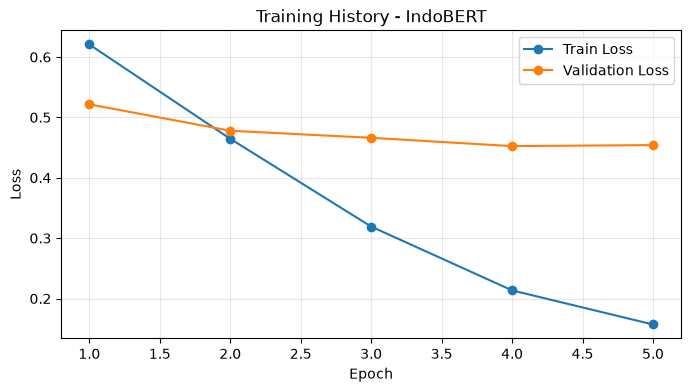

In [16]:
indobert_best_model, indobert_history = train_model(
    model=indobert_model,
    train_loader=indobert_train_loader,
    val_loader=indobert_val_loader,
    model_name="IndoBERT",
    tokenizer=indobert_tokenizer,
    output_dir=INDOBERT_OUTPUT_DIR,
)


display(indobert_history)
plot_training_history(indobert_history, "IndoBERT")


### Penentuan Threshold IndoBERT


In [17]:
(
    indobert_val_probabilities,
    indobert_val_labels,
    indobert_val_loss,
) = predict_probabilities(indobert_best_model, indobert_val_loader)

if OPTIMIZE_THRESHOLD:
    indobert_threshold, indobert_threshold_search = find_best_global_threshold(
        indobert_val_labels,
        indobert_val_probabilities,
    )
else:
    indobert_threshold = DEFAULT_THRESHOLD
    indobert_threshold_search = pd.DataFrame(
        [{"threshold": DEFAULT_THRESHOLD}]
    )

print("Threshold terbaik IndoBERT:", indobert_threshold)
display(indobert_threshold_search)


Threshold terbaik IndoBERT: 0.35


,threshold,f1_micro,f1_macro
0,0.20,0.648855,0.639751
1,0.25,0.672131,0.652179
2,0.30,0.683761,0.662820
3,0.35,0.687500,0.656848
4,0.40,0.682464,0.644503
5,0.45,0.686275,0.647194
6,0.50,0.680412,0.631507
7,0.55,0.659574,0.617038
8,0.60,0.637838,0.598120
9,0.65,0.636872,0.595942


### Classification Report IndoBERT


In [18]:
(
    indobert_test_probabilities,
    indobert_test_labels,
    indobert_test_loss,
) = predict_probabilities(indobert_best_model, indobert_test_loader)

indobert_test_predictions = probabilities_to_predictions(
    indobert_test_probabilities,
    indobert_threshold,
)

indobert_classification_report = build_classification_report(
    "IndoBERT",
    indobert_test_labels,
    indobert_test_predictions,
)

display(indobert_classification_report)


,model,label,precision,recall,f1-score,support
0,IndoBERT,PENOLAKAN_KEBIJAKAN,0.720000,0.818182,0.765957,66.0
1,IndoBERT,DUKUNGAN_KEBIJAKAN,0.678571,0.612903,0.644068,31.0
2,IndoBERT,KRITIK_PEMERINTAHAN,0.794872,0.704545,0.746988,44.0
3,IndoBERT,NETRAL,0.632911,0.833333,0.719424,60.0
4,IndoBERT,micro avg,0.696833,0.766169,0.729858,201.0
5,IndoBERT,macro avg,0.706589,0.742241,0.719109,201.0
6,IndoBERT,weighted avg,0.704004,0.766169,0.729116,201.0
7,IndoBERT,samples avg,0.741135,0.806147,0.745626,201.0


### Evaluation Model IndoBERT


In [19]:
indobert_metrics = pd.DataFrame(
    [
        {
            **calculate_multilabel_metrics(
                indobert_test_labels,
                indobert_test_predictions,
                model_name="IndoBERT",
            ),
            "test_loss": indobert_test_loss,
            "threshold": indobert_threshold,
        }
    ]
)

display(indobert_metrics)


,model,subset_accuracy,label_accuracy,hamming_loss,precision_micro,recall_micro,f1_micro,precision_macro,recall_macro,f1_macro,f1_weighted,jaccard_samples,test_loss,threshold
0,IndoBERT,0.468085,0.797872,0.202128,0.696833,0.766169,0.729858,0.706589,0.742241,0.719109,0.729116,0.671395,0.444242,0.35


### Confusion Matrix IndoBERT


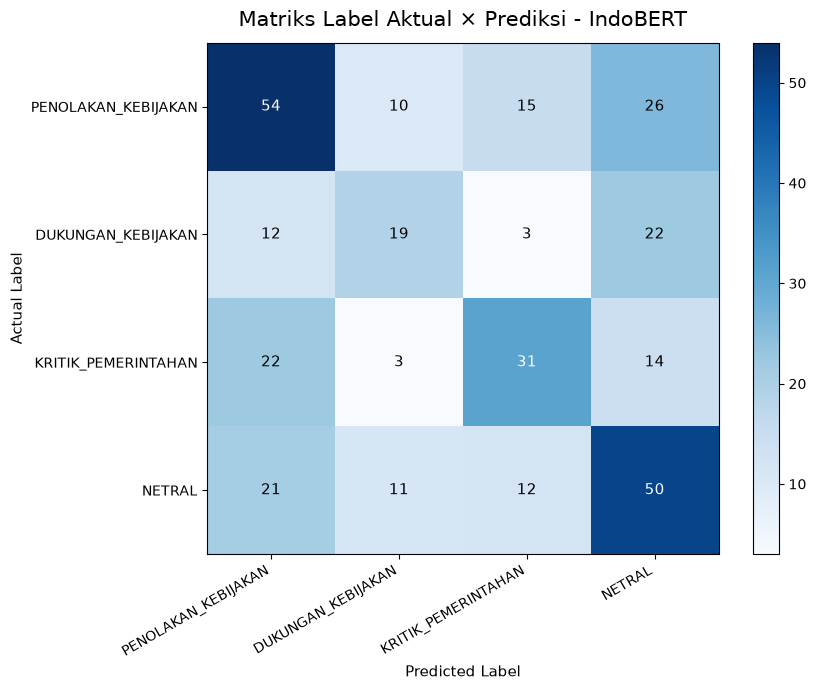

In [20]:
indobert_confusion_4x4 = plot_confusion_matrix(
    y_true=indobert_test_labels,
    y_pred=indobert_test_predictions,
    label_names=ACCEPT_LABELS,
    model_name="IndoBERT",
    cmap="Blues"
)


In [21]:
(
    indobert_confusion_df,
    indobert_confusion_matrices,
) = build_confusion_dataframe(
    "IndoBERT",
    indobert_test_labels,
    indobert_test_predictions,
)

display(indobert_confusion_df)


,model,label,true_negative,false_positive,false_negative,true_positive,total_data,accuracy,precision,recall,f1_score
0,IndoBERT,PENOLAKAN_KEBIJAKAN,54,21,12,54,141,0.765957,0.720000,0.818182,0.765957
1,IndoBERT,DUKUNGAN_KEBIJAKAN,101,9,12,19,141,0.851064,0.678571,0.612903,0.644068
2,IndoBERT,KRITIK_PEMERINTAHAN,89,8,13,31,141,0.851064,0.794872,0.704545,0.746988
3,IndoBERT,NETRAL,52,29,10,50,141,0.723404,0.632911,0.833333,0.719424


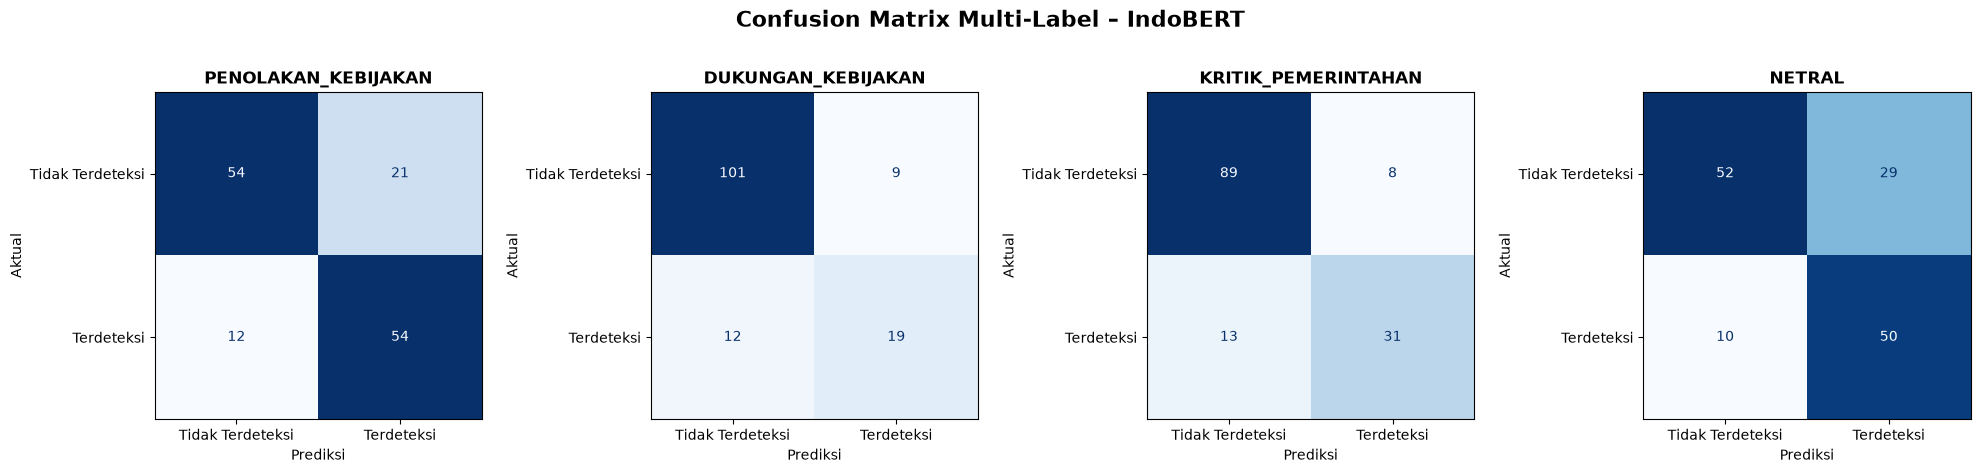

In [22]:
plot_multilabel_confusion(
    indobert_confusion_matrices,
    "IndoBERT",
    cmap=MODEL_CMAPS["IndoBERT"],
)


## NusaBERT


### Inisialisasi NusaBERT


In [23]:
NUSABERT_MODEL_ID = MODEL_NAMES["NusaBERT"]
NUSABERT_OUTPUT_DIR = OUTPUT_DIR / "NusaBERT"

nusabert_tokenizer = AutoTokenizer.from_pretrained(
    NUSABERT_MODEL_ID,
    use_fast=True,
)

nusabert_model = AutoModelForSequenceClassification.from_pretrained(
    NUSABERT_MODEL_ID,
    num_labels=len(ACCEPT_LABELS),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    problem_type="multi_label_classification",
)

(
    nusabert_train_loader,
    nusabert_val_loader,
    nusabert_test_loader,
) = create_data_loaders(nusabert_tokenizer)

print("Model       :", NUSABERT_MODEL_ID)
print("Output model:", NUSABERT_OUTPUT_DIR.resolve())


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at LazarusNLP/NusaBERT-base and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model       : LazarusNLP/NusaBERT-base
Output model: D:\Magister\Semester 2\Aplikasi Pembelajaran Mesin\UAS\Outputs\Deep Sequence\Multi Label\NusaBERT


### Training NusaBERT


NusaBERT - MULTI-LABEL TRAINING
[NusaBERT] Epoch 1/5 | train_loss=0.6595 | val_loss=0.6178 | val_f1_micro=0.2114
[NusaBERT] Epoch 2/5 | train_loss=0.6102 | val_loss=0.6073 | val_f1_micro=0.4099
[NusaBERT] Epoch 3/5 | train_loss=0.6117 | val_loss=0.6228 | val_f1_micro=0.1525
[NusaBERT] Epoch 4/5 | train_loss=0.6081 | val_loss=0.6202 | val_f1_micro=0.1368
Early stopping pada epoch 4.
NusaBERT - TRAINING HIS


,model,epoch,train_loss,val_loss,val_f1_micro,val_f1_macro,duration_seconds
0,NusaBERT,1,0.659515,0.617795,0.211382,0.161152,175.844037
1,NusaBERT,2,0.610245,0.607347,0.409938,0.280628,201.298748
2,NusaBERT,3,0.611750,0.622812,0.152542,0.114815,232.522688
3,NusaBERT,4,0.608060,0.620152,0.136752,0.105219,323.713291


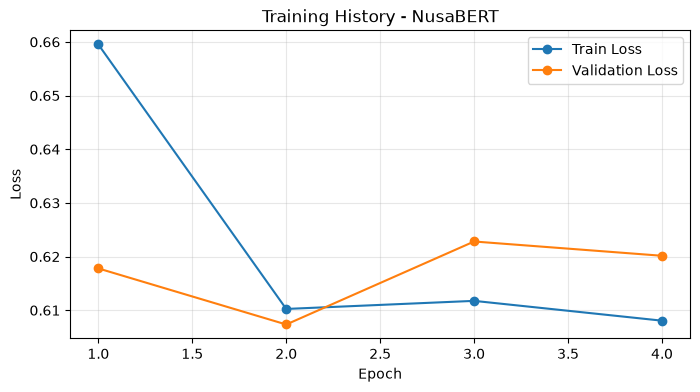

In [24]:
nusabert_best_model, nusabert_history = train_model(
    model=nusabert_model,
    train_loader=nusabert_train_loader,
    val_loader=nusabert_val_loader,
    model_name="NusaBERT",
    tokenizer=nusabert_tokenizer,
    output_dir=NUSABERT_OUTPUT_DIR,
)

display(nusabert_history)
plot_training_history(nusabert_history, "NusaBERT")


### Penentuan Threshold NusaBERT


In [25]:
(
    nusabert_val_probabilities,
    nusabert_val_labels,
    nusabert_val_loss,
) = predict_probabilities(nusabert_best_model, nusabert_val_loader)

if OPTIMIZE_THRESHOLD:
    nusabert_threshold, nusabert_threshold_search = find_best_global_threshold(
        nusabert_val_labels,
        nusabert_val_probabilities,
    )
else:
    nusabert_threshold = DEFAULT_THRESHOLD
    nusabert_threshold_search = pd.DataFrame(
        [{"threshold": DEFAULT_THRESHOLD}]
    )

print("Threshold terbaik NusaBERT:", nusabert_threshold)
display(nusabert_threshold_search)


Threshold terbaik NusaBERT: 0.35


,threshold,f1_micro,f1_macro
0,0.20,0.510989,0.482682
1,0.25,0.516923,0.480923
2,0.30,0.514493,0.438584
3,0.35,0.526316,0.421712
4,0.40,0.497561,0.362122
5,0.45,0.471910,0.330985
6,0.50,0.409938,0.280628
7,0.55,0.360000,0.252890
8,0.60,0.156522,0.095745
9,0.65,0.107143,0.068182


### Classification Report NusaBERT


In [26]:
(
    nusabert_test_probabilities,
    nusabert_test_labels,
    nusabert_test_loss,
) = predict_probabilities(nusabert_best_model, nusabert_test_loader)

nusabert_test_predictions = probabilities_to_predictions(
    nusabert_test_probabilities,
    nusabert_threshold,
)

nusabert_classification_report = build_classification_report(
    "NusaBERT",
    nusabert_test_labels,
    nusabert_test_predictions,
)

display(nusabert_classification_report)


,model,label,precision,recall,f1-score,support
0,NusaBERT,PENOLAKAN_KEBIJAKAN,0.520000,0.787879,0.626506,66.0
1,NusaBERT,DUKUNGAN_KEBIJAKAN,0.133333,0.064516,0.086957,31.0
2,NusaBERT,KRITIK_PEMERINTAHAN,0.454545,0.227273,0.303030,44.0
3,NusaBERT,NETRAL,0.495726,0.966667,0.655367,60.0
4,NusaBERT,micro avg,0.480315,0.606965,0.536264,201.0
5,NusaBERT,macro avg,0.400901,0.511584,0.417965,201.0
6,NusaBERT,weighted avg,0.438791,0.606965,0.481097,201.0
7,NusaBERT,samples avg,0.495272,0.615839,0.519385,201.0


### Evaluation Model NusaBERT


In [27]:
nusabert_metrics = pd.DataFrame(
    [
        {
            **calculate_multilabel_metrics(
                nusabert_test_labels,
                nusabert_test_predictions,
                model_name="NusaBERT",
            ),
            "test_loss": nusabert_test_loss,
            "threshold": nusabert_threshold,
        }
    ]
)

display(nusabert_metrics)


,model,subset_accuracy,label_accuracy,hamming_loss,precision_micro,recall_micro,f1_micro,precision_macro,recall_macro,f1_macro,f1_weighted,jaccard_samples,test_loss,threshold
0,NusaBERT,0.170213,0.625887,0.374113,0.480315,0.606965,0.536264,0.400901,0.511584,0.417965,0.481097,0.423168,0.609806,0.35


### Confusion Matrix NusaBERT


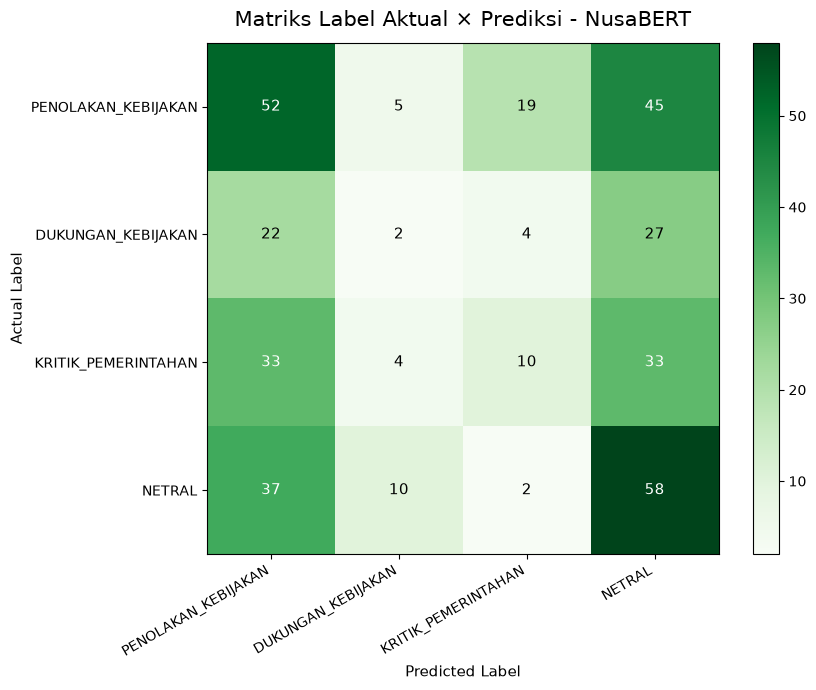

In [28]:
nusabert_confusion_4x4 = plot_confusion_matrix(
    y_true=nusabert_test_labels,
    y_pred=nusabert_test_predictions,
    label_names=ACCEPT_LABELS,
    model_name="NusaBERT",
    cmap="Greens"
)


In [29]:
(
    nusabert_confusion_df,
    nusabert_confusion_matrices,
) = build_confusion_dataframe(
    "NusaBERT",
    nusabert_test_labels,
    nusabert_test_predictions,
)


,model,label,true_negative,false_positive,false_negative,true_positive,total_data,accuracy,precision,recall,f1_score
0,NusaBERT,PENOLAKAN_KEBIJAKAN,27,48,14,52,141,0.560284,0.520000,0.787879,0.626506
1,NusaBERT,DUKUNGAN_KEBIJAKAN,97,13,29,2,141,0.702128,0.133333,0.064516,0.086957
2,NusaBERT,KRITIK_PEMERINTAHAN,85,12,34,10,141,0.673759,0.454545,0.227273,0.303030
3,NusaBERT,NETRAL,22,59,2,58,141,0.567376,0.495726,0.966667,0.655367


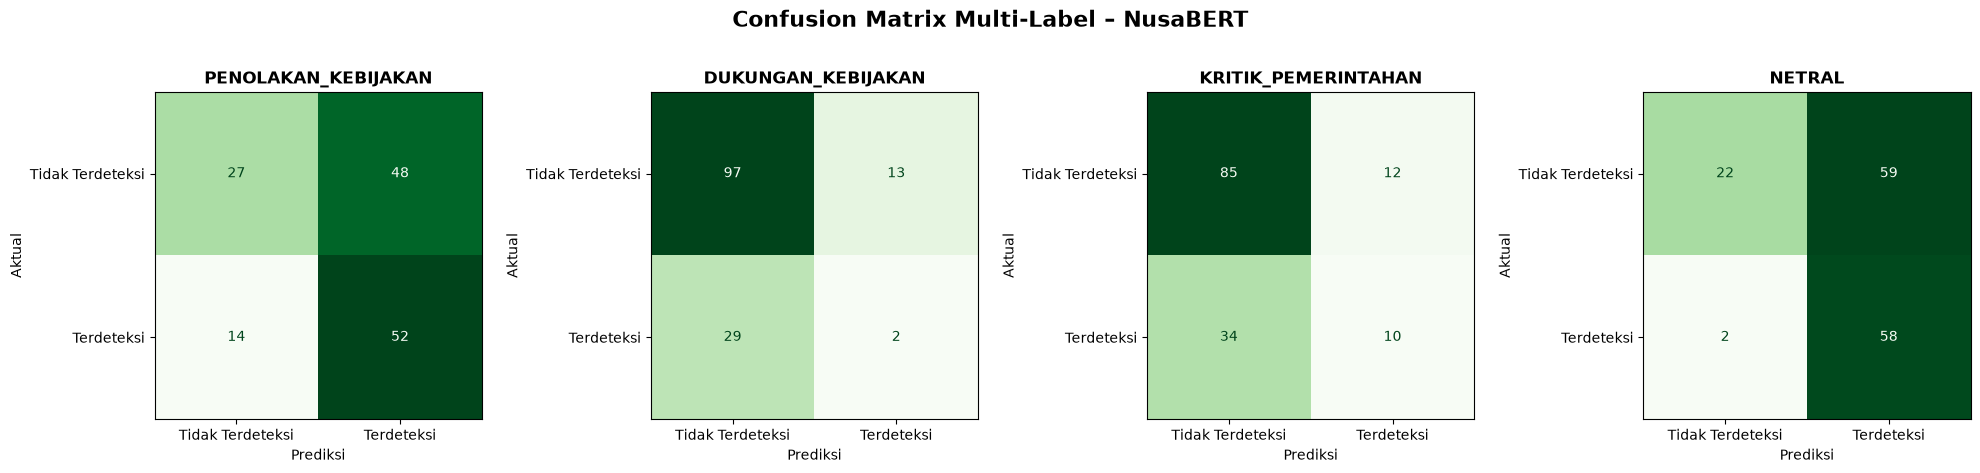

In [30]:
display(nusabert_confusion_df)
plot_multilabel_confusion(
    nusabert_confusion_matrices,
    "NusaBERT",
    cmap=MODEL_CMAPS["NusaBERT"],
)


# 8. Ringkasan Perbandingan IndoBERT dan NusaBERT


In [31]:
evaluation_summary_df = pd.concat(
    [
        indobert_metrics,
        nusabert_metrics,
    ],
    ignore_index=True,
).sort_values(
    by=["f1_micro", "hamming_loss"],
    ascending=[False, True],
).reset_index(drop=True)

print("Perbandingan metrik pada data test:")
display(evaluation_summary_df)

best_model_name = evaluation_summary_df.iloc[0]["model"]

print(
    "\nModel terbaik berdasarkan F1-micro tertinggi, "
    "kemudian Hamming Loss terendah:"
)
print(best_model_name)


Perbandingan metrik pada data test:


,model,subset_accuracy,label_accuracy,hamming_loss,precision_micro,recall_micro,f1_micro,precision_macro,recall_macro,f1_macro,f1_weighted,jaccard_samples,test_loss,threshold
0,IndoBERT,0.468085,0.797872,0.202128,0.696833,0.766169,0.729858,0.706589,0.742241,0.719109,0.729116,0.671395,0.444242,0.35
1,NusaBERT,0.170213,0.625887,0.374113,0.480315,0.606965,0.536264,0.400901,0.511584,0.417965,0.481097,0.423168,0.609806,0.35



Model terbaik berdasarkan F1-micro tertinggi, kemudian Hamming Loss terendah:
IndoBERT


# 9. Simpan Hasil Evaluasi


In [32]:
all_metrics_df = pd.concat(
    [indobert_metrics, nusabert_metrics],
    ignore_index=True,
)

all_reports_df = pd.concat(
    [
        indobert_classification_report,
        nusabert_classification_report,
    ],
    ignore_index=True,
)

all_confusion_df = pd.concat(
    [
        indobert_confusion_df,
        nusabert_confusion_df,
    ],
    ignore_index=True,
)

all_history_df = pd.concat(
    [
        indobert_history,
        nusabert_history,
    ],
    ignore_index=True,
)

all_thresholds_df = pd.concat(
    [
        indobert_threshold_search.assign(model="IndoBERT"),
        nusabert_threshold_search.assign(model="NusaBERT"),
    ],
    ignore_index=True,
)

indobert_cross_label_df = pd.DataFrame(
    indobert_confusion_4x4,
    index=ACCEPT_LABELS,
    columns=ACCEPT_LABELS,
)

nusabert_cross_label_df = pd.DataFrame(
    nusabert_confusion_4x4,
    index=ACCEPT_LABELS,
    columns=ACCEPT_LABELS,
)


def binary_rows_to_labels(binary_matrix):
    results = []
    for row in np.asarray(binary_matrix).astype(int):
        labels = [
            label
            for index, label in enumerate(ACCEPT_LABELS)
            if row[index] == 1
        ]
        results.append(", ".join(labels) if labels else "Tidak ada label")
    return results


def probability_rows_to_text(probability_matrix):
    return [
        "; ".join(
            f"{label}={row[index]:.4f}"
            for index, label in enumerate(ACCEPT_LABELS)
        )
        for row in np.asarray(probability_matrix)
    ]


test_predictions_df = pd.DataFrame(
    {
        "text": X_test.tolist(),
        "actual_labels": binary_rows_to_labels(indobert_test_labels),
        "IndoBERT_predictions": binary_rows_to_labels(
            indobert_test_predictions
        ),
        "IndoBERT_probabilities": probability_rows_to_text(
            indobert_test_probabilities
        ),
        "NusaBERT_predictions": binary_rows_to_labels(
            nusabert_test_predictions
        ),
        "NusaBERT_probabilities": probability_rows_to_text(
            nusabert_test_probabilities
        ),
    }
)

label_mapping_df = pd.DataFrame(
    {
        "label_id": range(len(ACCEPT_LABELS)),
        "label": ACCEPT_LABELS,
    }
)

EXCEL_RESULT_PATH = OUTPUT_DIR / "Multi_Label_evaluasi_deep_sequence.xlsx"

with pd.ExcelWriter(EXCEL_RESULT_PATH, engine="openpyxl") as writer:
    all_metrics_df.to_excel(writer, sheet_name="Metrics", index=False)
    all_reports_df.to_excel(
        writer,
        sheet_name="Classification_Report",
        index=False,
    )
    all_confusion_df.to_excel(
        writer,
        sheet_name="Confusion_Matrix_2x2",
        index=False,
    )
    indobert_cross_label_df.to_excel(
        writer,
        sheet_name="IndoBERT_Matrix_4x4",
        index=True,
    )
    nusabert_cross_label_df.to_excel(
        writer,
        sheet_name="NusaBERT_Matrix_4x4",
        index=True,
    )
    all_history_df.to_excel(
        writer,
        sheet_name="Training_History",
        index=False,
    )
    all_thresholds_df.to_excel(
        writer,
        sheet_name="Threshold_Search",
        index=False,
    )
    split_distribution_df.to_excel(
        writer,
        sheet_name="Split_Distribution",
        index=True,
    )
    label_distribution.to_excel(
        writer,
        sheet_name="Label_Distribution",
        index=True,
    )
    label_mapping_df.to_excel(
        writer,
        sheet_name="Label_Mapping",
        index=False,
    )
    test_predictions_df.to_excel(
        writer,
        sheet_name="Test_Predictions",
        index=False,
    )

# Simpan konfigurasi agar model mudah digunakan kembali.
config_path = OUTPUT_DIR / "multi_label_config.json"
with open(config_path, "w", encoding="utf-8") as file:
    json.dump(
        {
            "labels": ACCEPT_LABELS,
            "label2id": LABEL2ID,
            "id2label": ID2LABEL,
            "indobert_threshold": indobert_threshold,
            "nusabert_threshold": nusabert_threshold,
            "max_length": MAX_LENGTH,
            "best_model": best_model_name,
        },
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Model IndoBERT tersimpan di:")
print(INDOBERT_OUTPUT_DIR.resolve())
print("\nModel NusaBERT tersimpan di:")
print(NUSABERT_OUTPUT_DIR.resolve())
print("\nExcel evaluasi tersimpan di:")
print(EXCEL_RESULT_PATH.resolve())
print("\nKonfigurasi tersimpan di:")
print(config_path.resolve())


Model IndoBERT tersimpan di:
D:\Magister\Semester 2\Aplikasi Pembelajaran Mesin\UAS\Outputs\Deep Sequence\Multi Label\IndoBERT

Model NusaBERT tersimpan di:
D:\Magister\Semester 2\Aplikasi Pembelajaran Mesin\UAS\Outputs\Deep Sequence\Multi Label\NusaBERT

Excel evaluasi tersimpan di:
D:\Magister\Semester 2\Aplikasi Pembelajaran Mesin\UAS\Outputs\Deep Sequence\Multi Label\Multi_Label_evaluasi_deep_sequence.xlsx

Konfigurasi tersimpan di:
D:\Magister\Semester 2\Aplikasi Pembelajaran Mesin\UAS\Outputs\Deep Sequence\Multi Label\multi_label_config.json


# 10. Prediksi Data Baru


In [33]:
data_baru = [
    "Saya menolak kebijakan pembatasan akses internet karena merugikan masyarakat.",
    "Kebijakan bantuan pendidikan ini sangat baik dan layak didukung.",
    "Pemerintah dinilai tidak serius dan gagal menjalankan kebijakan perlindungan data.",
    "Pemerintah mengumumkan kebijakan pelayanan kesehatan baru mulai bulan depan.",
    "Saya mendukung tujuan program tersebut, tetapi mengkritik pemerintah karena pelaksanaannya tidak transparan.",
]

print("Jumlah data baru:", len(data_baru))
for nomor, teks in enumerate(data_baru, start=1):
    print(f"{nomor}. {teks}")


Jumlah data baru: 5
1. Saya menolak kebijakan pembatasan akses internet karena merugikan masyarakat.
2. Kebijakan bantuan pendidikan ini sangat baik dan layak didukung.
3. Pemerintah dinilai tidak serius dan gagal menjalankan kebijakan perlindungan data.
4. Pemerintah mengumumkan kebijakan pelayanan kesehatan baru mulai bulan depan.
5. Saya mendukung tujuan program tersebut, tetapi mengkritik pemerintah karena pelaksanaannya tidak transparan.


In [34]:
@torch.no_grad()
def predict_new_texts(
    model,
    tokenizer,
    texts,
    threshold,
    batch_size=16,
):
    model.eval()
    model.to(DEVICE)

    probabilities_all = []

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start : start + batch_size]
        encoded = tokenizer(
            batch_texts,
            truncation=True,
            padding=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        )
        encoded = {
            key: value.to(DEVICE)
            for key, value in encoded.items()
        }

        logits = model(**encoded).logits
        probabilities = torch.sigmoid(logits).cpu().numpy()
        probabilities_all.append(probabilities)

    probabilities_all = np.vstack(probabilities_all)
    predictions = probabilities_to_predictions(
        probabilities_all,
        threshold,
    )

    label_results = []
    probability_results = []

    for prediction, probabilities in zip(
        predictions,
        probabilities_all,
    ):
        detected = [
            label
            for index, label in enumerate(ACCEPT_LABELS)
            if prediction[index] == 1
        ]

        label_results.append(
            ", ".join(detected)
            if detected
            else "Tidak ada label terdeteksi"
        )

        probability_results.append(
            "; ".join(
                f"{label}={probabilities[index]:.3f}"
                for index, label in enumerate(ACCEPT_LABELS)
            )
        )

    return label_results, probability_results


(
    prediksi_indobert,
    probabilitas_indobert,
) = predict_new_texts(
    indobert_best_model,
    indobert_tokenizer,
    data_baru,
    indobert_threshold,
)

(
    prediksi_nusabert,
    probabilitas_nusabert,
) = predict_new_texts(
    nusabert_best_model,
    nusabert_tokenizer,
    data_baru,
    nusabert_threshold,
)


## Tabel Perbandingan Prediksi


In [35]:
hasil_prediksi = pd.DataFrame(
    {
        "Data": data_baru,
        "IndoBERT": prediksi_indobert,
        "Probabilitas IndoBERT": probabilitas_indobert,
        "NusaBERT": prediksi_nusabert,
        "Probabilitas NusaBERT": probabilitas_nusabert,
    }
)

hasil_tampil = hasil_prediksi.copy()
hasil_tampil.insert(0, "No", range(1, len(hasil_tampil) + 1))

tabel = (
    hasil_tampil.style
    .hide(axis="index")
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("vertical-align", "middle"),
                    ("padding", "10px"),
                    ("border", "1px solid black"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("vertical-align", "top"),
                    ("padding", "10px"),
                    ("border", "1px solid black"),
                ],
            },
            {
                "selector": "table",
                "props": [
                    ("border-collapse", "collapse"),
                    ("width", "100%"),
                ],
            },
        ]
    )
    .set_properties(
        subset=["No"],
        **{"text-align": "center", "width": "50px"},
    )
    .set_properties(
        subset=["Data"],
        **{
            "text-align": "left",
            "white-space": "normal",
            "word-wrap": "break-word",
            "min-width": "380px",
            "max-width": "560px",
        },
    )
    .set_properties(
        subset=[
            "IndoBERT",
            "NusaBERT",
            "Probabilitas IndoBERT",
            "Probabilitas NusaBERT",
        ],
        **{
            "text-align": "left",
            "white-space": "normal",
            "word-wrap": "break-word",
            "min-width": "210px",
            "max-width": "320px",
        },
    )
)

display(tabel)

PREDICTION_CSV_PATH = OUTPUT_DIR / "prediksi_data_baru.csv"
PREDICTION_EXCEL_PATH = OUTPUT_DIR / "prediksi_data_baru.xlsx"

hasil_prediksi.to_csv(
    PREDICTION_CSV_PATH,
    index=False,
    encoding="utf-8-sig",
)
hasil_prediksi.to_excel(
    PREDICTION_EXCEL_PATH,
    index=False,
)

print("Prediksi CSV tersimpan di :", PREDICTION_CSV_PATH.resolve())
print("Prediksi Excel tersimpan di:", PREDICTION_EXCEL_PATH.resolve())


No,Data,IndoBERT,Probabilitas IndoBERT,NusaBERT,Probabilitas NusaBERT
1,Saya menolak kebijakan pembatasan akses internet karena merugikan masyarakat.,"PENOLAKAN_KEBIJAKAN, KRITIK_PEMERINTAHAN",PENOLAKAN_KEBIJAKAN=0.482; DUKUNGAN_KEBIJAKAN=0.121; KRITIK_PEMERINTAHAN=0.779; NETRAL=0.068,"PENOLAKAN_KEBIJAKAN, NETRAL",PENOLAKAN_KEBIJAKAN=0.387; DUKUNGAN_KEBIJAKAN=0.123; KRITIK_PEMERINTAHAN=0.207; NETRAL=0.595
2,Kebijakan bantuan pendidikan ini sangat baik dan layak didukung.,"DUKUNGAN_KEBIJAKAN, KRITIK_PEMERINTAHAN",PENOLAKAN_KEBIJAKAN=0.103; DUKUNGAN_KEBIJAKAN=0.785; KRITIK_PEMERINTAHAN=0.431; NETRAL=0.100,"PENOLAKAN_KEBIJAKAN, NETRAL",PENOLAKAN_KEBIJAKAN=0.429; DUKUNGAN_KEBIJAKAN=0.134; KRITIK_PEMERINTAHAN=0.199; NETRAL=0.564
3,Pemerintah dinilai tidak serius dan gagal menjalankan kebijakan perlindungan data.,KRITIK_PEMERINTAHAN,PENOLAKAN_KEBIJAKAN=0.119; DUKUNGAN_KEBIJAKAN=0.189; KRITIK_PEMERINTAHAN=0.856; NETRAL=0.076,"PENOLAKAN_KEBIJAKAN, KRITIK_PEMERINTAHAN",PENOLAKAN_KEBIJAKAN=0.607; DUKUNGAN_KEBIJAKAN=0.244; KRITIK_PEMERINTAHAN=0.375; NETRAL=0.271
4,Pemerintah mengumumkan kebijakan pelayanan kesehatan baru mulai bulan depan.,KRITIK_PEMERINTAHAN,PENOLAKAN_KEBIJAKAN=0.118; DUKUNGAN_KEBIJAKAN=0.119; KRITIK_PEMERINTAHAN=0.835; NETRAL=0.197,"PENOLAKAN_KEBIJAKAN, KRITIK_PEMERINTAHAN",PENOLAKAN_KEBIJAKAN=0.641; DUKUNGAN_KEBIJAKAN=0.236; KRITIK_PEMERINTAHAN=0.362; NETRAL=0.318
5,"Saya mendukung tujuan program tersebut, tetapi mengkritik pemerintah karena pelaksanaannya tidak transparan.","PENOLAKAN_KEBIJAKAN, KRITIK_PEMERINTAHAN",PENOLAKAN_KEBIJAKAN=0.442; DUKUNGAN_KEBIJAKAN=0.267; KRITIK_PEMERINTAHAN=0.579; NETRAL=0.039,PENOLAKAN_KEBIJAKAN,PENOLAKAN_KEBIJAKAN=0.567; DUKUNGAN_KEBIJAKAN=0.314; KRITIK_PEMERINTAHAN=0.310; NETRAL=0.293


Prediksi CSV tersimpan di : D:\Magister\Semester 2\Aplikasi Pembelajaran Mesin\UAS\Outputs\Deep Sequence\Multi Label\prediksi_data_baru.csv
Prediksi Excel tersimpan di: D:\Magister\Semester 2\Aplikasi Pembelajaran Mesin\UAS\Outputs\Deep Sequence\Multi Label\prediksi_data_baru.xlsx


# 11. Memuat Model Tersimpan untuk Prediksi Tanpa Training Ulang

Bagian ini dapat digunakan pada sesi baru setelah model IndoBERT dan NusaBERT selesai disimpan.


In [36]:
def load_saved_multilabel_model(model_dir):
    model_dir = Path(model_dir)

    if not model_dir.exists():
        raise FileNotFoundError(
            f"Folder model tidak ditemukan: {model_dir.resolve()}"
        )

    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_dir
    ).to(DEVICE)

    return model, tokenizer


# Contoh penggunaan pada sesi baru:
#
# loaded_indobert_model, loaded_indobert_tokenizer = (
#     load_saved_multilabel_model(INDOBERT_OUTPUT_DIR)
# )
#
# label_prediksi, probabilitas_prediksi = predict_new_texts(
#     loaded_indobert_model,
#     loaded_indobert_tokenizer,
#     ["Masukkan teks baru di sini."],
#     threshold=indobert_threshold,
# )
#
# print(label_prediksi)
# print(probabilitas_prediksi)
